### $\color{indianred}{\text{ASTROSTATISTIKA - v9}} $

<hr style="border: none; height: 2px; background-color: indianred; opacity: 0.5;" />

In [2]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm, poisson, cauchy, iqr, uniform
from scipy.stats import kstwo, kstest, ks_2samp
from scipy.stats import mannwhitneyu, ranksums, wilcoxon, anderson, shapiro, ttest_ind, ttest_1samp, f
from urllib.request import urlopen
import matplotlib
matplotlib.rcParams.update({"text.usetex": False, "font.size" : 10, "font.family": "monospace"})

---

K-S test i drugi neparametarski testovi često su osjetljivi na više svojstava distribucije odjednom (lokacija, skala...). Kada nas zanima samo razlika u jednom svojstvu, npr. srednja vrijednost, koristimo testove bazirane na *rangovima* podataka, a ne njihovim vrijednostima.

**U test** testira da li su dva skupa podataka izvučena iz raspodjela sa različitim parametrima lokacije. Osjetljivošću testa dominira razlika medijana. Statistika $U$ se računa spajanjem oba uzorka, sortiranjem i dodjeljivanjem rangova. Za uzorke veće od $\sim20$ podataka može se koristiti:

$$
U_1 = R_1 - \frac{N_1(N_1 - 1)}{2},
$$

gdje je $R_1$ suma rangova uzorka 1; analogna procedura radi se za uzorak 2. Vrijedi provjera $U_1 + U_2 = N_1 N_2$. Usvojena statistika je $U = \min(U_1, U_2)$. Za velike uzorke, $U$ se dobro aproksimira normalnom raspodjelom $\mathcal{N}(\mu_U, \sigma_U)$, pa se računa:

$$
z = \frac{U - \mu_U}{\sigma_U},\quad\mu_U = \frac{N_1 N_2}{2}, \quad \sigma_U = \sqrt{\frac{N_1 N_2 (N_1 + N_2 + 1)}{12}}.
$$

**Vilkoksonov test** koristi se kada su uzorci upareni ($N_1 = N_2 = N$), npr. ista mjerenja prije i poslije nekog događaja. Računa se razlika:

$$
y_i = x_{1_i} - x_{2_i}.
$$

Parovi sa $y_i = 0$ se isključuju, preostalih $m$ parova se sortira po $|y_i|$ i dodjeljuju im se rangovi $R_i$. Svakom paru se dodjeljuje $\Phi_i = 1$ ako je $x1_i > x2_i$, inače $0$. Statistika je:

$$
W_+ = \sum_i^m \Phi_i R_i,
$$

tj. suma rangova gdje je $y_i > 0$. Analogno, $W_-$ je suma rangova gdje je $y_i < 0$, a usvojena statistika je $T = \min(W_+, W_-)$. Za $m \gtrsim 20$, $T$ se aproksimira sa $\mathcal{N}(\mu_T, \sigma_T)$:

$$
z = \frac{T - \mu_T}{\sigma_T},\quad\mu_T = \frac{N(2N+1)}{2}, \quad \sigma_T = N\sqrt{\frac{2N+1}{12}}.
$$

In [5]:
np.random.seed(0)

x, y = np.random.normal(0, 1, size=(2, 1000))
print(mannwhitneyu(x, y))

MannwhitneyuResult(statistic=482654.0, pvalue=0.17919398705643008)


In [ ]:
np.random.seed(0)

x = np.random.normal(-1, 1, 200)
y = np.random.normal(-0.5, 1.5, 300) 
print(ranksums(x, y))

x = np.random.normal(0, 1, 500)
y = np.random.uniform(-0.5, 0.5, 500) 
print(ranksums(x, y))

RanksumsResult(statistic=-2.6435517147698615, pvalue=0.008204123191145227)
RanksumsResult(statistic=-2.1280433697217225, pvalue=0.03333348790392057)


In [7]:
np.random.seed(0)

x, y = np.random.normal(0, 1, size=(2, 1000))
print(wilcoxon(x, y))

a = np.random.normal(0, 1, size=500)
b = np.random.uniform(0, 1, size=500)

print(wilcoxon(a, b))

WilcoxonResult(statistic=238373.0, pvalue=0.19357179019702442)
WilcoxonResult(statistic=29627.0, pvalue=1.8119410593156403e-24)


---

Kada se testira hipoteza *da li je $f(x)$ normalna raspodjela*, od interesa je samo parametar oblika, ne lokacija i skala. Odstupanja od normalne raspodjele mogu biti nenulta asimetrija, nenulti kurtozis, ili kombinacija ovo dvoje.

**Anderson-Darling test** mjeri koliko dobro podaci prate gausovski CDF. Statistika je:

$$
A^2 = -N - \frac{1}{N}\sum_{i=1}^{N}\left[(2i-1)\ln(F_i) + (2N - 2i + 1)\ln(1-F_i)\right],
$$

gdje je $F_i$ vrijednost CDF u tački $z_i$, a $z_i = \frac{x_i - \mu}{\sigma}$, uz podatke sortirane uzlazno. Ako su i $\mu$ i $\sigma$ procijenjeni iz podataka, $A^2$ se množi korekcijskim faktorom $(1 + 4/N - 25/N^2)$.

**Šapiro-Vilksov test** koristi i vrijednosti podataka $x_i$ i njihove rangove $R_i$:

$$
W = \frac{\left(\sum_{i=1}^N a_i R_i\right)^2}{\sum_{i=1}^N (x_i - \bar{x})^2},
$$

gdje konstante $a_i$ _kodiraju_ očekivane vrijednosti statistika *reda* za standardnu normalnu raspodjelu. Vrlo je osjetljiv na odstupajuće vrijednosti u repovima, ali manje na odstupanja u centru raspodjele.

K-S test se takođe može koristiti za poređenje $f(x)$ sa $\mathcal{N}(\mu, \sigma)$, ali ako su $\mu$ i $\sigma$ procijenjeni iz istih podataka, ponašanje statistike $Q_{KS}$ se mijenja i mora se odrediti Monte Karlo simulacijama.

In [ ]:
rng = np.random.default_rng(4)
x = rng.random(size = 50)
A, crit, sig =  anderson(x,"norm")
print(f"""Anderson-Darling statistika:  {A}
Kritične vrijednosti:  {crit}

Nivoi značajnosti:  {sig}""")

Anderson-Darling statistika:  0.8770622861248256
Kritične vrijednosti:  [0.538 0.613 0.736 0.858 1.021]
Nivoi značajnosti:  [15.  10.   5.   2.5  1. ]


In [1]:
# import warnings
# warnings.filterwarnings("ignore", category=UserWarning)
# import scipy
# print(f"Scipy verzija: {scipy.__version__}")

In [ ]:
np.random.seed(20)
x = np.random.normal(0, 1, 10000)
y = np.random.uniform(0, 1, 100)
print(shapiro(x))
print(shapiro(y))

ShapiroResult(statistic=0.9998840055606832, pvalue=0.9291707860449983)
ShapiroResult(statistic=0.9414681743586838, pvalue=0.00023720746163978678)


/home/zorzeus/anaconda3/envs/pymil/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:586: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 10000.
  res = hypotest_fun_out(*samples, **kwds)


______________________________________________________________________
Kolmogorov-Smirnov test: D = 0.0076  p = 0.6 
Anderson-Darling test: A^2 = 0.29
  značajnost  | kritična vrijednost 
    --------------|----------------
    15.0          | 0.6%
    10.0          | 0.7%
    5.0          | 0.8%
    2.5          | 0.9%
    1.0          | 1.1%
  Šapiro-Vilksov test: W = 1 p = 0.59
  Z_1 = 0.2
  Z_2 = 1.0
______________________________________________________________________
Kolmogorov-Smirnov test: D = 0.28  p = 0 
Anderson-Darling test: A^2 = 1.9e+02
  značajnost  | kritična vrijednost 
    --------------|----------------
    15.0          | 0.6%
    10.0          | 0.7%
    5.0          | 0.8%
    2.5          | 0.9%
    1.0          | 1.1%
  Šapiro-Vilksov test: W = 0.94 p = 7.5e-52
  Z_1 = 32.2
  Z_2 = 2.5


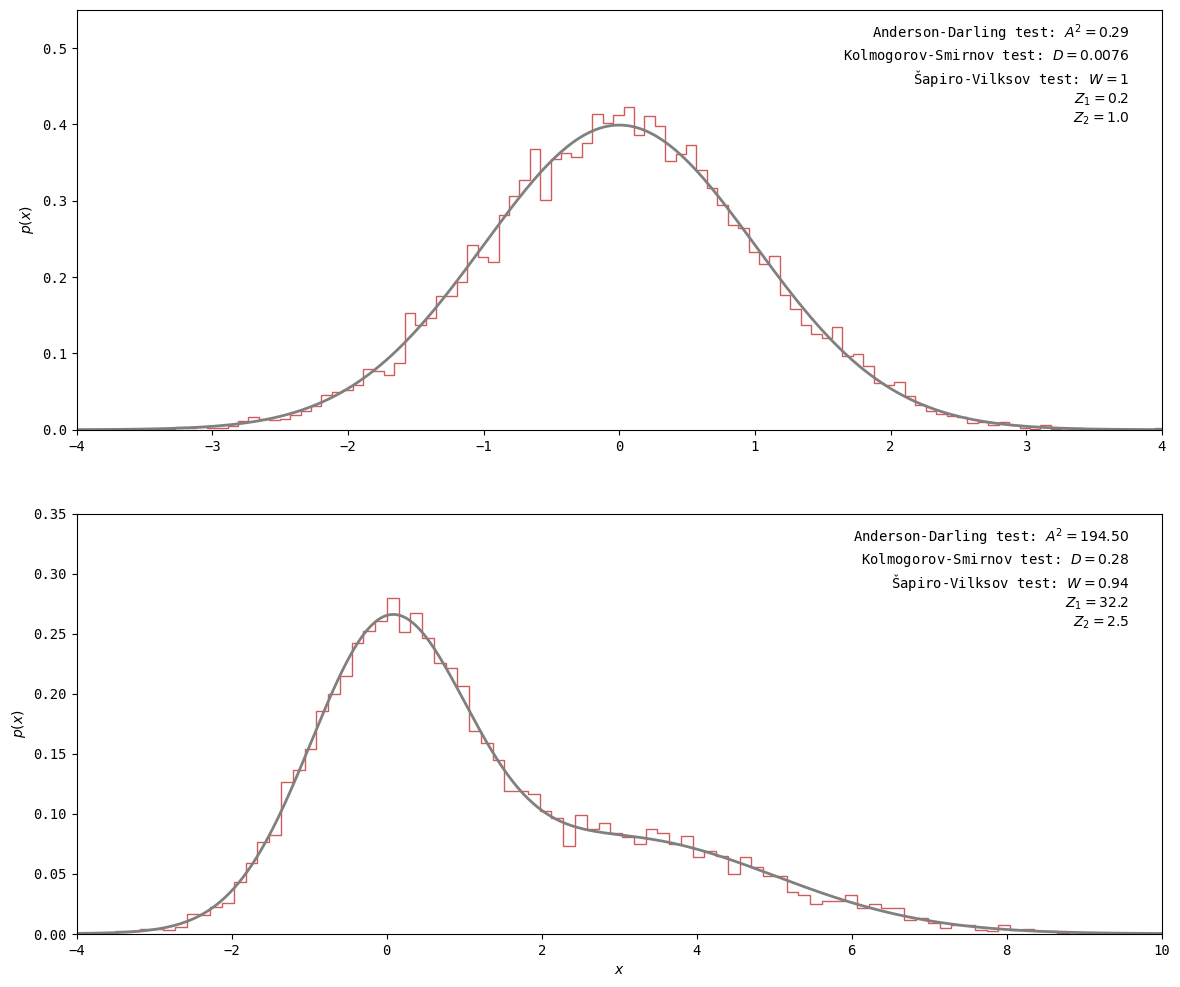

In [3]:
np.random.seed(1)
nv =norm(0, 1).rvs(10000)

dv = norm(0, 1).rvs(10000)
dv[:4000] = norm(3, 2).rvs(4000)

x = np.linspace(-4, 10, 1000)
normal_pdf = norm(0, 1).pdf(x)
dual_pdf = 0.6 * norm(0, 1).pdf(x) + 0.4 * norm(3, 2).pdf(x)

v = [nv, dv]
pdf = [normal_pdf, dual_pdf]
xlims = [(-4, 4), (-4, 10)]

plt.figure(figsize=(14, 12))

for i in range(2):
    mu = np.mean(v[i])
    sigma = np.std(v[i], ddof=1)
    med = np.median(v[i])
    sigmaG = iqr(v[i]) * 0.7413

    N = len(v[i])
    Z1 = 1.3 * abs(mu - med) / sigma * np.sqrt(N) # improvizovani Z test
    Z2 = 1.1 * abs(sigma / sigmaG - 1) * np.sqrt(N)

    A2, crit, sig = anderson(v[i])
    D, pD = kstest(v[i], "norm")
    W, pW = shapiro(v[i])

    print(70 * '_')
    print("Kolmogorov-Smirnov test: D = %.2g  p = %.2g " % (D, pD))
    print("Anderson-Darling test: A^2 = %.2g" % A2)
    print("  značajnost  | kritična vrijednost ")
    print("    --------------|----------------")
    for j in range(len(sig)):
        print("    {0:.1f}          | {1:.1f}%".format(sig[j], crit[j]))
    print("  Šapiro-Vilksov test: W = %.2g p = %.2g" % (W, pW))
    print("  Z_1 = %.1f" % Z1)
    print("  Z_2 = %.1f" % Z2)

    plt.subplot(2, 1, i + 1)
    plt.hist(v[i], bins=100, density=True, histtype='step', color='indianred')
    plt.plot(x, pdf[i], color='gray', lw=2)
    plt.xlim(xlims[i])
    plt.ylabel('$p(x)$')

    info = "Anderson-Darling test: $A^2 = %.2f$\n" % A2
    info += "Kolmogorov-Smirnov test: $D = %.2g$\n" % D
    info += "Šapiro-Vilksov test: $W = %.2g$\n" % W
    info += "$Z_1 = %.1f$\n$Z_2 = %.1f$" % (Z1, Z2)
    plt.gca().text(0.97, 0.97, info, ha='right', va='top', transform=plt.gca().transAxes)

    if i == 0:
        plt.ylim(0, 0.55)
    else:
        plt.ylim(0, 0.35)
        plt.xlabel('$x$')

plt.show()

---

Još jedno važno pitanje je - da li su dva uzorka $\{x_{1_i}\}$ i $\{x_{2_i}\}$ izvučena iz normalnih raspodjela s različitim $\mu$? Ako je $\sigma$ poznato, razlika $\Delta = \bar{x_1} - \bar{x_2}$ se normalizuje sa $\sigma_\Delta = \sigma\sqrt{1/N_1 + 1/N_2}$, pa važi $M_\sigma = \Delta/\sigma_\Delta$. Vjerovatnoća dobijanja ovako velike razlike slučajno je $p = 1 - \text{erf}(M/\sqrt{2})$. Ako $\sigma$ nije poznato i mora se procijeniti iz podataka ($s_1$, $s_2$), statistika

$$
t = \frac{\bar{x_1} - \bar{x_2}}{s_D},
$$

više nije normalna, već prati Studentovu $t$ raspodjelu sa $k = N_1 + N_2 - 2$ stepeni slobode, gdje je

$$
s_D = \sqrt{s_{12}^2\left(\frac{1}{N_1} + \frac{1}{N_2}\right)}, \qquad s_{12} = \sqrt{\frac{(N_1-1)s_1^2 + (N_2-1)s_2^2}{N_1 + N_2 - 2}}.
$$

Za velike uzorke važi $s \to \sigma$, pa $t$ raspodjela teži normalnoj.

Tzv. upareni **t-test** koristi se kada su $N_1 = N_2 = N$ i podaci su upareni (ista mjerenja u dva navrata), ali $\sigma$ nije isti za sve parove. Jednačina za $t$ ostaje ista, ali $s_D$ postaje:

$$
s_D = \sqrt{\frac{(N_1-1)s_1^2 + (N_2-1)s_2^2 - 2\,\text{Cov}_{12}}{N}},
$$

gdje je kovarijansa između uzoraka:

$$
\text{Cov}_{12} = \frac{1}{N-1}\sum_{i=1}^{N}(x_{1_i} - \bar{x_{1}})(x_{2_i} - \bar{x_2}).
$$

Broj stepeni slobode je $N - 1$.

In [11]:
np.random.seed(0)
rvs1 = norm.rvs(2, 8, 500)
rvs2 = norm.rvs(2, 8, 500) + norm.rvs(0,0.2,500)
print(ttest_ind(rvs1, rvs2))

rvs3 = norm.rvs(6, 8, 500)+ norm.rvs(0,0.2,500)
print(ttest_ind(rvs1, rvs3))

TtestResult(statistic=0.625416390541633, pvalue=0.5318407886123997, df=998.0)
TtestResult(statistic=-8.378738664093502, pvalue=1.8000707268010143e-16, df=998.0)


In [33]:
np.random.seed(2)
rvs_1 = uniform.rvs(0,1,size=50)
rvs_2 = norm.rvs(0,1,size=50)


print(ttest_1samp(rvs_1, popmean=0.5))
print(ttest_1samp(rvs_2, popmean=0.25))

TtestResult(statistic=-1.3317813022489975, pvalue=0.18909413335928232, df=49)
TtestResult(statistic=-2.228704895736087, pvalue=0.030452865388663347, df=49)


**F test** se koristi za poređenje varijansi dva uzorka $\{x1_i\}$ i $\{x2_i\}$ iz normalnih raspodjela. Nulta hipoteza je $\sigma_1^2 = \sigma_2^2$, a statistika je omjer varijansi uzoraka:

$$
F = \frac{s_1^2}{s_2^2}.
$$

$F$ prati Fišerovu $F$ raspojelu sa $d_1 = N_1 - 1$ i $d_2 = N_2 - 1$ stepenima slobode.

In [18]:
np.random.seed(0)
# from scipy.stats import f
x, y = np.random.normal(size=(2, 1000))
df1 = len(x) - 1
df2 = len(y) - 1
p = f(df1, df2).cdf(x.var() / y.var())
print(p)

0.7290828317467344


<hr style="border: none; height: 2px; background-color: magenta; opacity: 0.5;" />

$\color{magenta}{\text{Z1}}$ :


Prikupiti velike poluose i ekscentričnosti za asteroide sa linka 'http://asteroids.matf.bg.ac.rs/fam/proper/feb2020/afp.pro'.
Podijeliti ih na unutrašnji ($2.0<a<2.5\,\rm AJ$) i spoljašnji pojas ($2.8<a<3.2\,\rm AJ$). Ispitati normalnost preko Šapiro-Vilksovog testa. Da li je bolje primijeniti t test ili U test?

<hr style="border: none; height: 2px; background-color: magenta; opacity: 0.5;" />

$\color{magenta}{\text{R1}}$ : 